<a href="https://colab.research.google.com/github/jalil7777/AI_Business_Decision_Intelligence_Platform/blob/main/AI_Business_Decision_Intelligence_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Business Strategy & Executive Decision Intelligence Platform

A GenAI-powered notebook that analyzes **sales data**, **customer feedback**, and an optional **PDF market report** to produce:

- Sales KPIs (revenue, profit, cost, orders, AOV, margin)
- Monthly revenue/profit/order trends
- Period-over-period comparison
- Simple anomaly detection (>20% month-over-month revenue swings)
- Customer sentiment analysis + common feedback themes
- Rule-based business risks and opportunities
- An AI-generated executive summary (Google Gemini, with a local fallback if no API key is set)
- What-if scenario analysis (revenue/cost growth projections)
- An interactive AI business assistant (ask questions about the latest analysis)
- An interactive executive dashboard (charts + widgets)

This notebook re-implements the same logic as the original FastAPI web app
(`app.py` in the *AI-Business-Decision-Intelligence-Platform* project) so it can run
end-to-end inside Jupyter / Google Colab, using sample data or your own uploaded files.


## 1. Setup — install & import dependencies

In [1]:
# If a package is missing, uncomment the next line and run it once.
# !pip install pandas pypdf google-genai ipywidgets matplotlib --quiet

import io
import os
import json
from collections import Counter
from pathlib import Path
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt

try:
    from pypdf import PdfReader
    PYPDF_AVAILABLE = True
except ImportError:
    PYPDF_AVAILABLE = False
    print("pypdf not installed — PDF market report parsing will be skipped.")

try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not installed — interactive widgets will be skipped.")

print("Setup complete.")


pypdf not installed — PDF market report parsing will be skipped.
Setup complete.


## 2. Configure Gemini (optional)

The dashboard works fully **without** an API key — it falls back to a local,
rule-based executive summary. If you have a Gemini API key, set it below (or
as an environment variable `GEMINI_API_KEY`) to get AI-generated summaries and
a real conversational business assistant.


In [2]:
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")  # or paste your key directly as a string

# Uncomment and set this if you want to hardcode a key for this session:
# GEMINI_API_KEY = "your_real_api_key"

if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

try:
    from google import genai
    GENAI_AVAILABLE = True
except ImportError:
    GENAI_AVAILABLE = False
    if GEMINI_API_KEY:
        print("google-genai not installed. Run: pip install google-genai")

print("Gemini configured." if GEMINI_API_KEY else "No Gemini key set — local summaries will be used.")


No Gemini key set — local summaries will be used.


## 3. Sample data

If you don't have your own files, this cell generates sample `sales.csv` and
`customer_feedback.csv` data (matching the schema the original project expects),
so you can run the whole notebook immediately. Replace this with your own
uploaded files in Section 4 if you prefer.


In [3]:
import numpy as np
import random
from datetime import date, timedelta

random.seed(42)
np.random.seed(42)

regions = ["North", "South", "East", "West"]
products = ["Alpha Phone", "Beta Tablet", "Gamma Watch", "Delta Speaker"]
categories = {"Alpha Phone": "Electronics", "Beta Tablet": "Electronics",
              "Gamma Watch": "Wearables", "Delta Speaker": "Audio"}

rows = []
start = date(2025, 1, 1)
for day_offset in range(240):  # ~8 months of daily transactions
    d = start + timedelta(days=day_offset)
    for _ in range(random.randint(2, 6)):
        product = random.choice(products)
        orders = random.randint(1, 10)
        revenue = round(orders * random.uniform(50, 400), 2)
        cost = round(revenue * random.uniform(0.55, 0.8), 2)
        rows.append({
            "Date": d.isoformat(),
            "Region": random.choice(regions),
            "Product": product,
            "Category": categories[product],
            "Revenue": revenue,
            "Cost": cost,
            "Profit": round(revenue - cost, 2),
            "Orders": orders,
            "Customers": random.randint(1, orders),
        })

sample_sales_df = pd.DataFrame(rows)
sample_sales_df.to_csv("sales.csv", index=False)

feedback_texts = [
    "Delivery was fast and the packaging was excellent.",
    "The battery life is poor and support was slow to respond.",
    "Great value for the price, very reliable product.",
    "Setup was easy but tracking information was unclear.",
    "Delayed shipment caused a lot of inconvenience.",
    "Quality exceeded my expectations, very attractive design.",
    "Price is a bit expensive but the product feels premium.",
    "Damaged item on arrival, quality control problem.",
    "Simple setup, good instructions, satisfied overall.",
    "Support team resolved my issue quickly, good service.",
]
feedback_rows = [{"Rating": random.randint(1, 5), "Feedback": random.choice(feedback_texts)} for _ in range(150)]
sample_feedback_df = pd.DataFrame(feedback_rows)
sample_feedback_df.to_csv("customer_feedback.csv", index=False)

print("Sample sales.csv and customer_feedback.csv generated.")
sample_sales_df.head()


Sample sales.csv and customer_feedback.csv generated.


,Date,Region,Product,Category,Revenue,Cost,Profit,Orders,Customers
0,2025-01-01,North,Alpha Phone,Electronics,678.56,396.88,281.68,5,5
1,2025-01-01,South,Alpha Phone,Electronics,1976.73,1101.93,874.80,10,4
2,2025-01-02,West,Alpha Phone,Electronics,1076.34,766.86,309.48,9,4
3,2025-01-02,South,Delta Speaker,Audio,1473.67,1130.78,342.89,10,7
4,2025-01-02,East,Gamma Watch,Wearables,522.09,412.09,110.00,5,1


## 4. Load your own files (optional)

Skip this cell to keep using the generated sample data above. To use your own
files instead, upload them (in Colab, use the file browser or `files.upload()`)
and set the paths below.


In [4]:
SALES_CSV_PATH = "sales.csv"                 # required
FEEDBACK_CSV_PATH = "customer_feedback.csv"   # optional — set to None to skip
REPORT_PDF_PATH = None                        # optional — set to a .pdf path to include a market report

def read_bytes(path):
    if not path:
        return b""
    p = Path(path)
    return p.read_bytes() if p.exists() else b""

sales_bytes = read_bytes(SALES_CSV_PATH)
feedback_bytes = read_bytes(FEEDBACK_CSV_PATH)
report_bytes = read_bytes(REPORT_PDF_PATH)

print(f"Sales file loaded: {len(sales_bytes)} bytes")
print(f"Feedback file loaded: {len(feedback_bytes)} bytes")
print(f"Report file loaded: {len(report_bytes)} bytes")


Sales file loaded: 62273 bytes
Feedback file loaded: 8373 bytes
Report file loaded: 0 bytes


## 5. Core analysis functions

In [5]:
def safe_number(value):
    """Convert NumPy values into normal Python numbers for JSON."""
    if pd.isna(value):
        return 0
    return float(value)


def percentage_change(current, previous):
    """Calculate percentage change without division-by-zero errors."""
    if previous == 0:
        return 0.0
    return round(((current - previous) / previous) * 100, 2)


def prepare_sales(file_bytes):
    """Read, validate and clean the uploaded sales CSV."""
    try:
        sales = pd.read_csv(io.BytesIO(file_bytes))
    except Exception as error:
        raise ValueError(f"Could not read sales CSV: {error}")

    required = {
        "Date", "Region", "Product", "Category", "Revenue",
        "Cost", "Profit", "Orders", "Customers"
    }
    missing = required - set(sales.columns)
    if missing:
        raise ValueError(f"Missing sales columns: {', '.join(sorted(missing))}")

    sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
    numeric_columns = ["Revenue", "Cost", "Profit", "Orders", "Customers"]
    for column in numeric_columns:
        sales[column] = pd.to_numeric(sales[column], errors="coerce")

    sales = sales.dropna(subset=["Date", *numeric_columns]).drop_duplicates()
    if sales.empty:
        raise ValueError("The sales CSV has no valid records.")
    return sales


def calculate_sales_analysis(sales):
    """Calculate KPIs, trends, comparisons and anomalies."""
    revenue = sales["Revenue"].sum()
    profit = sales["Profit"].sum()
    cost = sales["Cost"].sum()
    orders = sales["Orders"].sum()
    customers = sales["Customers"].sum()

    kpis = {
        "total_revenue": safe_number(revenue),
        "total_profit": safe_number(profit),
        "total_cost": safe_number(cost),
        "total_orders": int(orders),
        "total_customers": int(customers),
        "average_order_value": round(safe_number(revenue / orders), 2) if orders else 0,
        "profit_margin": round(safe_number((profit / revenue) * 100), 2) if revenue else 0,
    }

    monthly = (
        sales.assign(Month=sales["Date"].dt.to_period("M").astype(str))
        .groupby("Month", as_index=False)[["Revenue", "Profit", "Orders"]]
        .sum()
        .sort_values("Month")
    )

    latest = monthly.iloc[-1]
    previous = monthly.iloc[-2] if len(monthly) > 1 else latest

    comparison = {
        "current_period": latest["Month"],
        "previous_period": previous["Month"],
        "revenue_change": percentage_change(latest["Revenue"], previous["Revenue"]),
        "profit_change": percentage_change(latest["Profit"], previous["Profit"]),
        "orders_change": percentage_change(latest["Orders"], previous["Orders"]),
    }

    monthly["Revenue_Change"] = monthly["Revenue"].pct_change() * 100
    anomaly_rows = monthly[monthly["Revenue_Change"].abs() > 20]
    anomalies = [
        {
            "period": row["Month"],
            "change": round(row["Revenue_Change"], 2),
            "message": f"Revenue changed by {row['Revenue_Change']:.1f}% in {row['Month']}.",
        }
        for _, row in anomaly_rows.iterrows()
    ]

    region = (
        sales.groupby("Region", as_index=False)[["Revenue", "Profit"]]
        .sum().sort_values("Revenue", ascending=False)
    )
    product = (
        sales.groupby("Product", as_index=False)[["Revenue", "Profit", "Orders"]]
        .sum().sort_values("Revenue", ascending=False)
    )

    return {
        "kpis": kpis,
        "comparison": comparison,
        "anomalies": anomalies,
        "monthly": monthly[["Month", "Revenue", "Profit", "Orders"]].to_dict("records"),
        "regions": region.to_dict("records"),
        "products": product.to_dict("records"),
    }


POSITIVE_WORDS = {
    "excellent", "good", "great", "fast", "easy", "reliable",
    "attractive", "exceeded", "simple", "value"
}
NEGATIVE_WORDS = {
    "bad", "delayed", "late", "damaged", "poor", "slow", "unclear",
    "problem", "lower", "stopped", "inconvenience", "expensive"
}
THEMES = ["delivery", "battery", "packaging", "support", "price", "quality", "tracking", "setup"]


def sentiment_label(text):
    """A small rule-based sentiment method with no ML download required."""
    words = set(str(text).lower().replace(".", "").replace(",", "").split())
    score = len(words & POSITIVE_WORDS) - len(words & NEGATIVE_WORDS)
    if score > 0:
        return "Positive"
    if score < 0:
        return "Negative"
    return "Neutral"


def analyze_feedback(file_bytes):
    """Read feedback CSV and calculate sentiment and common themes."""
    if not file_bytes:
        return {"total": 0, "average_rating": 0, "sentiment": {}, "themes": []}

    try:
        feedback = pd.read_csv(io.BytesIO(file_bytes))
    except Exception as error:
        raise ValueError(f"Could not read feedback CSV: {error}")

    required = {"Rating", "Feedback"}
    missing = required - set(feedback.columns)
    if missing:
        raise ValueError(f"Missing feedback columns: {', '.join(sorted(missing))}")

    feedback["Rating"] = pd.to_numeric(feedback["Rating"], errors="coerce")
    feedback = feedback.dropna(subset=["Rating", "Feedback"]).drop_duplicates()
    feedback["Sentiment"] = feedback["Feedback"].apply(sentiment_label)
    counts = feedback["Sentiment"].value_counts().to_dict()

    theme_counter = Counter()
    all_feedback = " ".join(feedback["Feedback"].astype(str)).lower()
    for theme in THEMES:
        theme_counter[theme] = all_feedback.count(theme)

    return {
        "total": int(len(feedback)),
        "average_rating": round(safe_number(feedback["Rating"].mean()), 2),
        "sentiment": {
            "Positive": int(counts.get("Positive", 0)),
            "Neutral": int(counts.get("Neutral", 0)),
            "Negative": int(counts.get("Negative", 0)),
        },
        "themes": [
            {"name": name.title(), "count": count}
            for name, count in theme_counter.most_common(5)
            if count > 0
        ],
    }


def extract_pdf_text(file_bytes):
    """Extract text from an optional PDF market report."""
    if not file_bytes:
        return "No market report was uploaded."
    if not PYPDF_AVAILABLE:
        return "pypdf is not installed; skipping PDF market report parsing."
    try:
        reader = PdfReader(io.BytesIO(file_bytes))
        return " ".join(page.extract_text() or "" for page in reader.pages)[:12000]
    except Exception as error:
        raise ValueError(f"Could not read PDF report: {error}")


def build_rules(analysis, feedback):
    """Create transparent risks and opportunities from business rules."""
    comparison = analysis["comparison"]
    kpis = analysis["kpis"]
    risks, opportunities = [], []

    if comparison["revenue_change"] < 0:
        risks.append("Latest-month revenue declined compared with the previous month.")
    if comparison["profit_change"] < comparison["revenue_change"]:
        risks.append("Profit is growing more slowly than revenue, indicating margin pressure.")
    if feedback["sentiment"].get("Negative", 0) > feedback["sentiment"].get("Positive", 0) * 0.4:
        risks.append("Negative feedback is relatively high and needs management attention.")
    if kpis["profit_margin"] < 20:
        risks.append("Overall profit margin is below 20%.")

    best_region = analysis["regions"][0]["Region"]
    best_product = analysis["products"][0]["Product"]
    opportunities.append(f"Expand successful activities from the {best_region} region.")
    opportunities.append(f"Increase promotion and inventory planning for {best_product}.")
    if feedback["average_rating"] >= 4:
        opportunities.append("Use strong customer satisfaction in marketing campaigns.")

    return risks or ["No major rule-based risk was detected."], opportunities


def local_executive_summary(analysis, feedback, risks, opportunities):
    """Fallback summary shown when no Gemini API key is configured."""
    kpis = analysis["kpis"]
    comparison = analysis["comparison"]
    return (
        f"The business generated total revenue of INR {kpis['total_revenue']:,.0f} "
        f"and profit of INR {kpis['total_profit']:,.0f}, with a {kpis['profit_margin']:.1f}% margin. "
        f"In {comparison['current_period']}, revenue changed by {comparison['revenue_change']:.1f}% "
        f"and profit changed by {comparison['profit_change']:.1f}% from the previous month. "
        f"Customer feedback averages {feedback['average_rating']:.1f}/5. "
        f"Priority: {risks[0]} Recommended action: {opportunities[0]}"
    )


def ask_gemini(prompt):
    """Call Gemini only when GEMINI_API_KEY is available."""
    api_key = os.getenv("GEMINI_API_KEY")
    if not api_key or not GENAI_AVAILABLE:
        return None
    try:
        client = genai.Client(api_key=api_key)
        response = client.models.generate_content(model="gemini-3.5-flash", contents=prompt)
        return response.text
    except Exception:
        return None

print("Core functions defined.")


Core functions defined.


## 6. Run the full analysis

In [6]:
sales = prepare_sales(sales_bytes)
sales_analysis = calculate_sales_analysis(sales)
feedback_analysis = analyze_feedback(feedback_bytes)
report_text = extract_pdf_text(report_bytes)
risks, opportunities = build_rules(sales_analysis, feedback_analysis)

prompt = f"""
You are a senior business strategy analyst. Use only the supplied facts.
Write a short executive summary followed by three actionable recommendations.

KPIs: {sales_analysis['kpis']}
Period comparison: {sales_analysis['comparison']}
Customer feedback: {feedback_analysis}
Risks: {risks}
Opportunities: {opportunities}
Market report context: {report_text[:5000]}
"""

summary = ask_gemini(prompt) or local_executive_summary(
    sales_analysis, feedback_analysis, risks, opportunities
)

LATEST_ANALYSIS = {
    **sales_analysis,
    "feedback": feedback_analysis,
    "risks": risks,
    "opportunities": opportunities,
    "executive_summary": summary,
    "ai_enabled": bool(os.getenv("GEMINI_API_KEY")),
}

print("Analysis complete.\n")
print(json.dumps(LATEST_ANALYSIS["kpis"], indent=2))


Analysis complete.

{
  "total_revenue": 1229586.19,
  "total_profit": 400974.37,
  "total_cost": 828611.8200000001,
  "total_orders": 5287,
  "total_customers": 3101,
  "average_order_value": 232.57,
  "profit_margin": 32.61
}


## 7. Executive summary, risks & opportunities

In [7]:
print("EXECUTIVE SUMMARY")
print("=" * 60)
print(LATEST_ANALYSIS["executive_summary"])

print("\nRISKS")
print("=" * 60)
for r in LATEST_ANALYSIS["risks"]:
    print(f"- {r}")

print("\nOPPORTUNITIES")
print("=" * 60)
for o in LATEST_ANALYSIS["opportunities"]:
    print(f"- {o}")

print("\nANOMALIES")
print("=" * 60)
if LATEST_ANALYSIS["anomalies"]:
    for a in LATEST_ANALYSIS["anomalies"]:
        print(f"- {a['message']}")
else:
    print("No anomalies detected (no month moved more than 20%).")


EXECUTIVE SUMMARY
The business generated total revenue of INR 1,229,586 and profit of INR 400,974, with a 32.6% margin. In 2025-08, revenue changed by -29.9% and profit changed by -31.1% from the previous month. Customer feedback averages 2.9/5. Priority: Latest-month revenue declined compared with the previous month. Recommended action: Expand successful activities from the West region.

RISKS
- Latest-month revenue declined compared with the previous month.
- Profit is growing more slowly than revenue, indicating margin pressure.
- Negative feedback is relatively high and needs management attention.

OPPORTUNITIES
- Expand successful activities from the West region.
- Increase promotion and inventory planning for Alpha Phone.

ANOMALIES
- Revenue changed by -29.9% in 2025-08.


## 8. Interactive executive dashboard (charts)

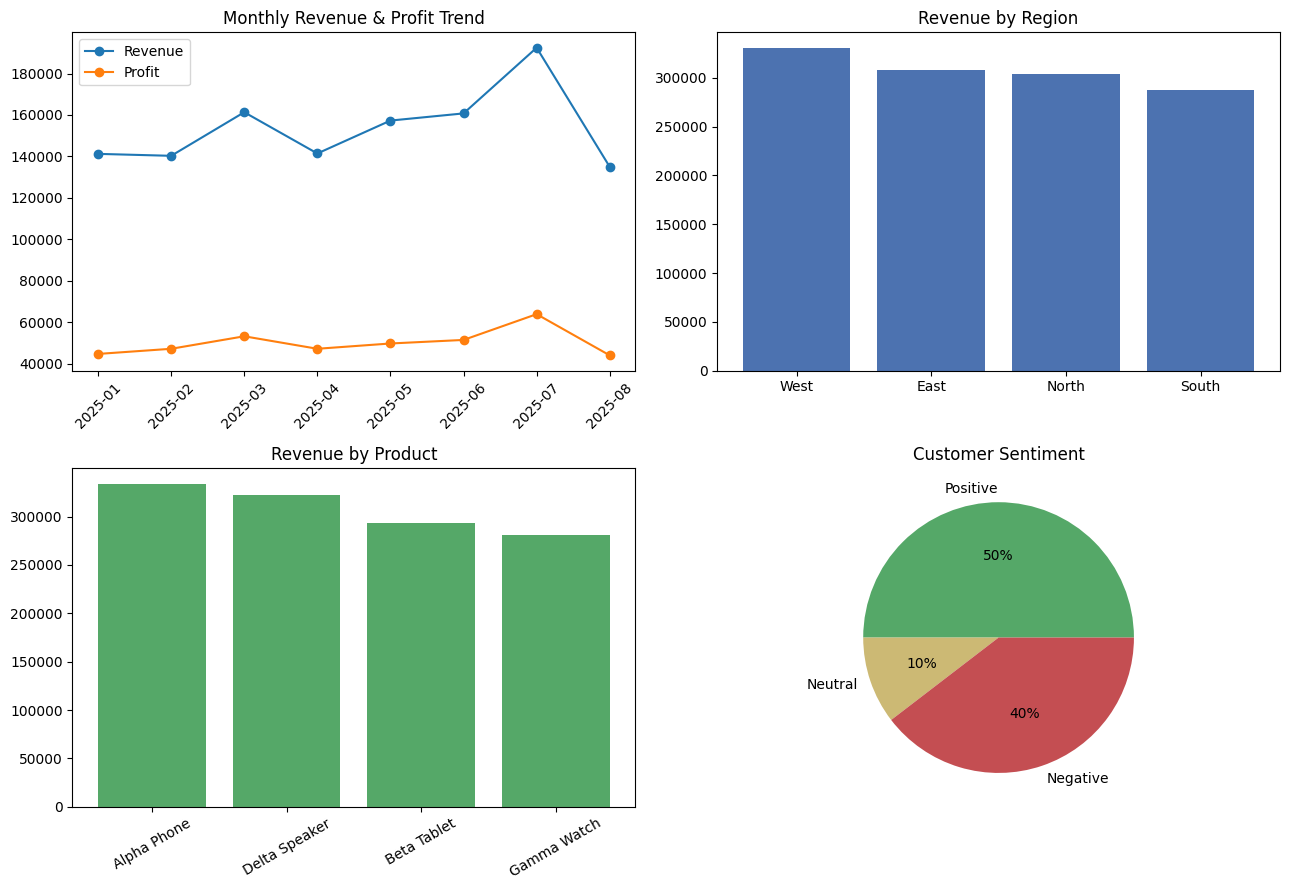

In [8]:
monthly_df = pd.DataFrame(LATEST_ANALYSIS["monthly"])
region_df = pd.DataFrame(LATEST_ANALYSIS["regions"])
product_df = pd.DataFrame(LATEST_ANALYSIS["products"])
feedback_sentiment = LATEST_ANALYSIS["feedback"]["sentiment"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Monthly revenue & profit trend
axes[0, 0].plot(monthly_df["Month"], monthly_df["Revenue"], marker="o", label="Revenue")
axes[0, 0].plot(monthly_df["Month"], monthly_df["Profit"], marker="o", label="Profit")
axes[0, 0].set_title("Monthly Revenue & Profit Trend")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()

# Revenue by region
axes[0, 1].bar(region_df["Region"], region_df["Revenue"], color="#4C72B0")
axes[0, 1].set_title("Revenue by Region")

# Revenue by product
axes[1, 0].bar(product_df["Product"], product_df["Revenue"], color="#55A868")
axes[1, 0].set_title("Revenue by Product")
axes[1, 0].tick_params(axis="x", rotation=30)

# Customer sentiment
if feedback_sentiment:
    axes[1, 1].pie(
        feedback_sentiment.values(),
        labels=feedback_sentiment.keys(),
        autopct="%1.0f%%",
        colors=["#55A868", "#CCB974", "#C44E52"],
    )
    axes[1, 1].set_title("Customer Sentiment")
else:
    axes[1, 1].axis("off")
    axes[1, 1].set_title("No feedback data")

plt.tight_layout()
plt.show()


## 9. What-if scenario analysis

Project revenue and profit under different revenue/cost growth assumptions —
matches the `/api/scenario` endpoint in the original app.


In [9]:
def run_scenario(revenue_growth=10.0, cost_growth=6.0):
    """Calculate a simple what-if business scenario."""
    if not LATEST_ANALYSIS:
        raise ValueError("Analyze the business files first.")
    kpis = LATEST_ANALYSIS["kpis"]
    projected_revenue = kpis["total_revenue"] * (1 + revenue_growth / 100)
    projected_cost = kpis["total_cost"] * (1 + cost_growth / 100)
    projected_profit = projected_revenue - projected_cost
    return {
        "projected_revenue": round(projected_revenue, 2),
        "projected_cost": round(projected_cost, 2),
        "projected_profit": round(projected_profit, 2),
        "profit_change": percentage_change(projected_profit, kpis["total_profit"]),
    }


if WIDGETS_AVAILABLE:
    revenue_slider = widgets.FloatSlider(value=10, min=-50, max=100, step=1, description="Revenue growth %")
    cost_slider = widgets.FloatSlider(value=6, min=-50, max=100, step=1, description="Cost growth %")
    scenario_output = widgets.Output()

    def on_scenario_change(change=None):
        with scenario_output:
            clear_output(wait=True)
            result = run_scenario(revenue_slider.value, cost_slider.value)
            print(json.dumps(result, indent=2))

    revenue_slider.observe(on_scenario_change, names="value")
    cost_slider.observe(on_scenario_change, names="value")
    on_scenario_change()
    display(widgets.VBox([revenue_slider, cost_slider, scenario_output]))
else:
    print(run_scenario(10, 6))


## 10. AI business assistant

Ask free-form questions about the latest analysis — matches the `/api/chat`
endpoint in the original app. Uses Gemini if configured, otherwise falls back
to the executive summary.


In [10]:
def ask_business_assistant(question):
    """Ask Gemini about the latest analysis."""
    if not LATEST_ANALYSIS:
        raise ValueError("Analyze the business files first.")
    prompt = f"""
Answer the executive's question using only this business analysis:
{LATEST_ANALYSIS}

Question: {question}
Keep the answer clear, practical and under 180 words.
"""
    answer = ask_gemini(prompt)
    if not answer:
        answer = (
            "Gemini is not configured. Set GEMINI_API_KEY to enable live Q&A. "
            f"Current executive summary: {LATEST_ANALYSIS['executive_summary']}"
        )
    return answer


if WIDGETS_AVAILABLE:
    question_box = widgets.Text(
        value="Which region should we invest in next quarter?",
        description="Question:",
        layout=widgets.Layout(width="600px"),
    )
    ask_button = widgets.Button(description="Ask")
    chat_output = widgets.Output()

    def on_ask_clicked(b):
        with chat_output:
            clear_output(wait=True)
            print(ask_business_assistant(question_box.value))

    ask_button.on_click(on_ask_clicked)
    display(widgets.VBox([question_box, ask_button, chat_output]))
else:
    print(ask_business_assistant("Which region should we invest in next quarter?"))


---
### Notes

- This notebook mirrors the logic of the original FastAPI project (`app.py`) —
  the same KPI, trend, anomaly, sentiment, risk/opportunity, and scenario
  calculations — adapted to run as a self-contained Jupyter/Colab notebook
  instead of a web server.
- To use your **own** sales/feedback/report files, edit the paths in
  **Section 4** and re-run from there.
- To enable real AI-generated summaries and Q&A, install `google-genai` and
  set `GEMINI_API_KEY` in **Section 2**.
